In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/aiwithcagri/wind-turbine-gearbox-anomaly-detection-5year-scada/turbine_5yr_labeled_data.csv
/kaggle/input/datasets/aiwithcagri/wind-turbine-gearbox-anomaly-detection-5year-scada/turbine_5yr_complex_data.csv


In [2]:
df = pd.read_csv('/kaggle/input/datasets/aiwithcagri/wind-turbine-gearbox-anomaly-detection-5year-scada/turbine_5yr_labeled_data.csv')
df = df.drop('timestamp',axis=1)
df.head(3)

,gearbox_oil_temp,gearbox_bearing_temp,vibration_x,vibration_y,vibration_z,oil_pressure,particle_count,is_anomaly
0,60.49,67.06,0.0129,0.0119,0.0149,4.41,120,0
1,59.88,67.18,0.0125,0.0115,0.0143,4.43,120,0
2,60.35,66.80,0.0090,0.0083,0.0104,4.31,120,0


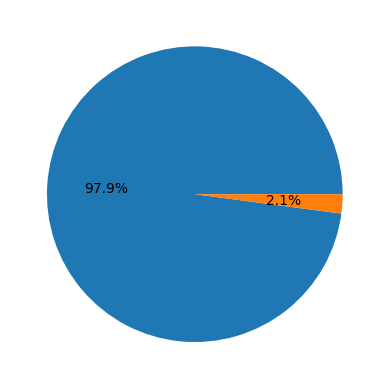

In [3]:
import matplotlib.pyplot as plt
vc = df['is_anomaly'].value_counts()

plt.pie(vc.values,autopct="%1.1f%%")
plt.show()

In [4]:
from sklearn.ensemble import IsolationForest
from sklearn.model_selection import train_test_split

In [5]:
x = df.drop('is_anomaly',axis=1)
y = df['is_anomaly']

x_train,x_test,y_train,y_test = train_test_split(x,y,train_size=0.88,random_state=42,stratify=y)

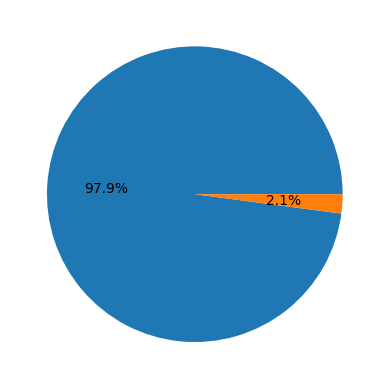

In [6]:
vc = y_test.value_counts()

plt.pie(vc.values,autopct="%1.1f%%")
plt.show()

In [7]:
iso = IsolationForest(contamination=y.mean())
model = iso.fit(x_train)

In [8]:
tahmin = pd.DataFrame()

In [9]:
tahmin['y_pred'] = model.predict(x_test)

In [10]:
tahmin['y_pred'] = np.where(tahmin['y_pred'] == 1,0,1)

In [11]:
tahmin['y_pred'].value_counts()

y_pred
0    30877
1      659
Name: count, dtype: int64

In [12]:
tahmin['y'] = y_test.values

In [13]:
from sklearn.metrics import f1_score,precision_score,recall_score

In [14]:
f1_score(tahmin['y'],tahmin['y_pred'])

0.9871114480667172

In [15]:
precision_score(tahmin['y'],tahmin['y_pred'])

0.9878603945371776

In [16]:
recall_score(tahmin['y'],tahmin['y_pred'])

0.9863636363636363